# Лабораторная работа №3

In [35]:
import pandas as pd
import sklearnex
from daal4py.sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB


sklearnex.patch_sklearn()
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
RANDOM_STATE = 13

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [36]:
data = pd.read_csv("datasets/neo.csv", index_col="Unnamed: 0")
data

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,-0.889019,-0.892421,0.316109,-1.612480,0.892109,0
1,-0.405274,-0.407831,-1.593181,-0.196165,0.406521,0
2,0.043918,0.042145,0.286110,1.266990,-0.044382,0
3,-0.750806,-0.753967,-0.258175,-1.094244,0.753369,0
4,0.734983,0.734416,0.777089,1.531822,-0.738079,0
...,...,...,...,...,...,...
90831,-0.819912,-0.823194,-0.982506,-1.585159,0.822739,0
90832,0.562217,0.561348,-0.921528,-0.158712,-0.564655,0
90833,-0.301614,-0.303991,2.706200,0.789522,0.302466,0
90834,-0.128848,-0.130923,-0.090366,-0.452655,0.129042,0


In [37]:
data["hazardous"].value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

Существует большой дисбаланс классов. Количество неопасных объектов гораздо больше количества опасных объектов.

Text(0, 0.5, 'counts')

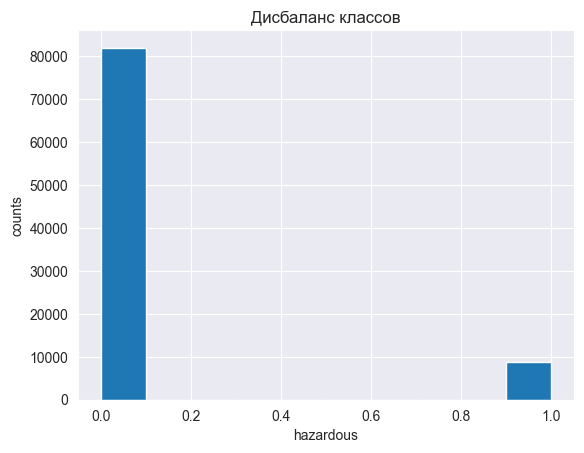

In [38]:
data["hazardous"].hist()
plt.title("Дисбаланс классов")
plt.xlabel("hazardous")
plt.ylabel("counts")

## Разделение выборки и балансировка классов

In [39]:
random_state = 13
X = data.drop("hazardous", axis=1)
y = data["hazardous"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state = RANDOM_STATE, stratify=y)
X_test, X_val, y_test, y_val  = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state = RANDOM_STATE, stratify=y_val_test)

print(f"Размер исходной выборки: {len(X)}\n"
      f"Размер тренировочной выборки: {len(X_train)}\n"
      f"Размер валидационной выборки: {len(X_val)}\n"
      f"Размер тестовой выборки: {len(X_test)}")

Размер исходной выборки: 90836
Размер тренировочной выборки: 72668
Размер валидационной выборки: 9084
Размер тестовой выборки: 9084


In [40]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [41]:
print("Доля классов в исходных данных:\n", y.value_counts(normalize=True))
print("\nДоля в тренировочной выборке:\n", y_train_res.value_counts(normalize=True))
print("\nДоля в валидационной выборке:\n", y_val.value_counts(normalize=True))
print("\nДоля в тестовой выборке:\n", y_test.value_counts(normalize=True))

Доля классов в исходных данных:
 hazardous
0    0.902682
1    0.097318
Name: proportion, dtype: float64

Доля в тренировочной выборке:
 hazardous
0    0.5
1    0.5
Name: proportion, dtype: float64

Доля в валидационной выборке:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64

Доля в тестовой выборке:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64


## Подготовка к обучению модели

In [42]:
import optuna
from sklearn.metrics import mean_squared_error, f1_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


def train_models_with_val(X_train, y_train, X_val, y_val, models_config):

    result={}

    for name, reg_info in models_config.items():

        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["model"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(),
            scoring="f1",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(),
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            score = f1_score(y_val, model.predict(X_val)) # максимизируем на валидационной выборке
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

In [43]:
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline


def train_models_with_cross_val(X_train, y_train, models_config):

    result={}

    skf = StratifiedKFold(n_splits=10, random_state=RANDOM_STATE, shuffle=True)
    smote = SMOTE(random_state=RANDOM_STATE)

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_obj = model_info["model"]

        pipeline = Pipeline(smote, model_obj)
        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator= pipeline,
            scoring="f1",
            cv=skf
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=pipeline,
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=skf
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            current_pipe = Pipeline([
                smote,
                model_obj(**trial_params,random_state=RANDOM_STATE)
            ])

            score = cross_val_score(current_pipe, X_train, y_train, cv=skf, scoring='f1').mean()
            return score

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        final_optuna_pipe = Pipeline([
            smote,
            model_obj(**study.best_params, random_state=RANDOM_STATE)
        ])
        final_optuna_pipe.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": final_optuna_pipe,
            "best_params": study.best_params
        }

    return result

In [44]:
columns1 = []
columns2 = []

metrics = ["F1", "Accuracy", "Precision", "Recall"]
for type_of_data in ["Train Data", "Test Data"]:
    for metric in metrics:
        columns1.append(type_of_data + " " + metric)

for type_of_division in ["Метод hold-out", "Метод k-fold"]:
    for metric in metrics:
        columns2.append(type_of_division + " " + metric)

train_test_table = pd.DataFrame(columns=columns1)
hold_kfold_table = pd.DataFrame(columns=columns2)
train_test_table

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall


In [45]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]
    results = [
        round(f1_score(y_test, y_predicted), 2),
        round(accuracy_score(y_test, y_predicted), 4),
        round(precision_score(y_test, y_predicted), 4),
        round(recall_score(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

In [46]:
def input_metrics_into_the_train_test_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test):
    sk_learn_test_metrics = get_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = get_metrics(y_train, predict_on_train_y)

    train_test_table.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

In [47]:
def input_metrics_into_the_hold_kfold_table(name_of_model, hold_model, kfold_model, X_test, y_test):
    kfold_model_predict = kfold_model.predict(X_test)
    hold_model_predict = hold_model.predict(X_test)

    kfold_model_metrics = get_metrics(y_test, kfold_model_predict)

    hold_model_metrics = get_metrics(y_train, hold_model_predict)

    hold_kfold_table.loc[name_of_model] = hold_model_metrics + kfold_model_metrics

## Обучение моделей

In [52]:
from sklearnex.svm import SVC
import numpy as np

models_grid = {
    "Logistic regression":{
        "model": LogisticRegression,
        "param_grid":
            {
                "C": [0.1, 1, 10, 100],
                "penalty": ["l2"],
                "solver": ["lbfgs"]

            }
    },
    "KNN_euclidean":
        {
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["euclidean"]
            }
        },
    "KNN_manhattan":{
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["manhattan"]
            }
        },
    "KNN_chebyshev":{
        "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["chebyshev"]
            }
    },

    "Naive_Bayes":{
        "model": GaussianNB,
        "param_grid":{
            "var_smoothing": np.logspace(-3, 1, num=20)
        }
    },

    "SVM_linear":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto", 0.1 , 10],
            "kernel": ["linear"],
        }
    },
    "SVM_poly":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto", 0.1 , 10],
            "kernel": ["poly"],
            "degree": [2, 3]
        }
    },

    "SVM_rbf":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto", 0.1 , 10],
            "kernel": ["rbf"],
        }
    },

     "SVM_sigmoid":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto", 0.1 , 10],
            "kernel": ["sigmoid"],
        }
    },
}

In [ ]:
val_models = train_models_with_val(X_train, y_train, X_val, y_val, models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[I 2026-04-01 20:59:40,296] A new study created in memory with name: no-name-c036317b-477c-4618-80ea-c3bdb295532a
[I 2026-04-01 20:59:40,316] Trial 0 finished with value: 0.11743450767841011 and parameters: {'C': 9.239810487525919, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.11743450767841011.
[I 2026-04-01 20:59:40,336] Trial 1 finished with value: 0.11743450767841011 and parameters: {'C': 23.972899179999928, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.11743450767841011.
[I 2026-04-01 20:59:40,357] Trial 2 finished with value: 0.11573236889692586 and parameters: {'C': 1.0495887363380514, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.11743450767841011.
[I 20